In [ ]:
!pip install yfinance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
gold_data = yf.download('GC=F', start='2000-01-01', end='2025-01-01')

# Fix column issue
gold_data.columns = gold_data.columns.get_level_values(0)

gold_data.head()

/tmp/ipykernel_14347/519203034.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_data = yf.download('GC=F', start='2000-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2000-08-30,273.899994,273.899994,273.899994,273.899994,0
2000-08-31,278.299988,278.299988,274.799988,274.799988,0
2000-09-01,277.000000,277.000000,277.000000,277.000000,0
2000-09-05,275.799988,275.799988,275.799988,275.799988,2
2000-09-06,274.200012,274.200012,274.200012,274.200012,0


In [ ]:
usd_inr = yf.download('INR=X', start='2000-01-01', end='2025-01-01')

# Fix column issue
usd_inr.columns = usd_inr.columns.get_level_values(0)

usd_inr.head()

/tmp/ipykernel_14347/2083823011.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  usd_inr = yf.download('INR=X', start='2000-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2003-12-01,45.709999,45.728001,45.615002,45.709000,0
2003-12-02,45.629002,45.719002,45.560001,45.709000,0
2003-12-03,45.549999,45.655998,45.474998,45.632000,0
2003-12-04,45.548000,45.612999,45.519001,45.548000,0
2003-12-05,45.449001,45.566002,45.449001,45.549999,0


In [ ]:
gold_close = gold_data['Close']
usd_close = usd_inr['Close']

gold_df = pd.DataFrame({'Gold_USD': gold_close})
usd_df = pd.DataFrame({'USD_INR': usd_close})

gold_data = pd.merge(gold_df, usd_df, left_index=True, right_index=True)

gold_data['Gold_INR'] = gold_data['Gold_USD'] * gold_data['USD_INR']

gold_data.head()

,Gold_USD,USD_INR,Gold_INR
Date,,,
2003-12-01,402.700012,45.709999,18407.417189
2003-12-02,403.700012,45.629002,18420.428510
2003-12-03,403.899994,45.549999,18397.644414
2003-12-04,403.299988,45.548000,18369.507979
2003-12-05,406.399994,45.449001,18470.473856


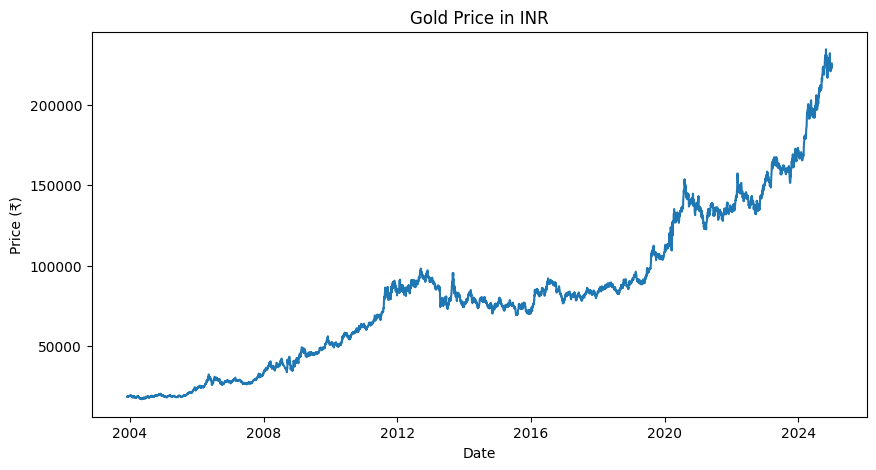

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(gold_data['Gold_INR'])

plt.title('Gold Price in INR')
plt.xlabel('Date')        # X-axis label
plt.ylabel('Price (₹)')   # Y-axis label

plt.show()

In [ ]:
gold_data['Year'] = gold_data.index.year

X = gold_data[['Year']]
y = gold_data['Gold_INR']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [ ]:
gold_data['Prev_Close'] = gold_data['Gold_INR'].shift(1)
gold_data = gold_data.dropna()

X_rf = gold_data[['Prev_Close']]
y_rf = gold_data['Gold_INR']

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, shuffle=False
)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

rf_pred = rf_model.predict(X_test_rf)

In [ ]:
print("Linear Regression MAE:", mean_absolute_error(y_test, lr_pred))
print("Random Forest MAE:", mean_absolute_error(y_test_rf, rf_pred))

Linear Regression MAE: 32674.070274175814
Random Forest MAE: 14832.757474803762


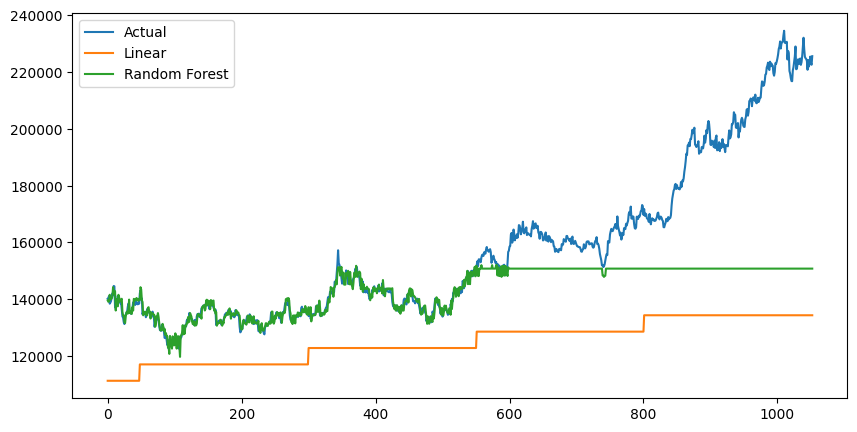

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(lr_pred, label='Linear')
plt.plot(rf_pred, label='Random Forest')
plt.legend()
plt.show()

In [ ]:
print("\nFuture Predictions:")

# Linear Regression
future_years = np.array([2026, 2027, 2028]).reshape(-1,1)
lr_future = lr_model.predict(future_years)

print("\nLinear Regression:")
for year, price in zip(future_years, lr_future):
    print(f"{year[0]} → ₹{float(price):.2f}")

# Random Forest
last_price = gold_data['Gold_INR'].iloc[-1]

rf_future = []
years = [2026, 2027, 2028]

for i in range(3):
    pred = rf_model.predict([[last_price]])[0]
    rf_future.append(pred)
    last_price = pred

print("\nRandom Forest:")
for year, price in zip(years, rf_future):
    print(f"{year} → ₹{price:.2f}")


Future Predictions:

Linear Regression:
2026 → ₹145915.01
2027 → ₹151677.74
2028 → ₹157440.46

Random Forest:
2026 → ₹150802.91
2027 → ₹151789.73
2028 → ₹148259.55


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
